#<font color="blue"> **Project 2: Prediction of Breast Cancer Tumours using xgboost**

# <font color="green">**Project Introduction**</font>



##### <font color="blue"> 1.1 Health Data Science Question </font>

  
  * The health data science question is to classify breast tumors as malignant (0) or benign (1) by training a fully connected neural network (FNN) on 30 digitised medical features extracted from diagnostic images.

##### <font color="blue"> 1.2 Method Evaluation - Success Criteria </font>

* Both False Negatives (a benign tumor being misclassified as malignant) and False Positives (a malignant tumor being misclassified as benign) carry significant consequences. The latter can cause a delay in life-saving treatment, but the former can result in unnecessary psychological distress, medical procedures, and costs.

* The F1-score provides a balanced measure that simultaneously accounts for False Positives and False Negatives by being the harmonic mean of precision and recall. The F1-score offers a more comprehensive indicator of model success than metrics based on solely one aspect, such as accuracy, precision or recall by considering both error types.

* Therefore, we set **macro F1-score** as our primary success criterion because it provides a balanced measure that accounts for both classes equally.


* As the secondary evaluation metric, we select **malignant recall** (treating malignant as the positive class) because it directly measures the model’s ability to correctly identify malignant tumors and avoid the clinically critical error of misclassifying them as benign.

##### <font color="blue"> 1.3 Dataset </font>

* The Breast Cancer Wisconsin (Diagnostic) dataset contains 569 instances and 30 numerical attributes derived from digitised images of fine needle aspirate (FNA) of breast masses.

* Each tumor sample includes measurements of 10 core cell nucleus features—including radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. For each of these 10 features, the dataset provides three values: the mean, the standard error, and the worst (largest) value, resulting in a total of 30 features per sample.

* These features help in distinguishing between benign and malignant tumors. The dataset includes a binary target class: malignant (WDBC-M) and benign (WDBC-B).

Reference: https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset



##### <font color="blue"> 1.4 Table of Software and Libraries </font>

* All libraries used in this notebook are listed below with comments describing their use

In [ ]:
# Load the breast cancer dataset from scikit-learn for model building in section 2.1
from sklearn.datasets import load_breast_cancer

# Split the dataset into training, validation, and test sets in section 2.2
from sklearn.model_selection import train_test_split

# Standardize features to place them on the same scale in section 2.2
from sklearn.preprocessing import StandardScaler

# Reshape target variable y to match the expected format for tf.keras.metrics.F1Score in section 2.2
import numpy as np

# Build the ANN: define layers (Dense, Input) and assemble models.Sequential in section 3
from tensorflow.keras import layers, models

# Use TensorFlow core to set random seed, Adam optimizer, and F1Score metric in section 3
import tensorflow as tf

# Perform random search to find optimal hyperparameters in section 3.3
import keras_tuner as kt

# Load a saved model created in section 3 for evaluation in section 4
from tensorflow.keras.models import load_model

# Evaluate the model using classification report and confusion matrix in section 4
from sklearn.metrics import classification_report, confusion_matrix

# Plot the confusion matrix for better interpretability in section 4
import matplotlib.pyplot as plt


##### <font color="blue"> 1.5 Table of Variables and Constants </font>

* **data:** Breast cancer dataset object loaded from load_breast_cancer() containing features and target.
* **X:** Feature matrix
* **y:** Target Vector
* **scaler:** StandardScaler object used to standardise features based on training set statistics.
* **X_train:** Training set features after splitting and standardisation.
* **X_val:** Validation set features after splitting and standardisation.
* **X_test:** Test set features after splitting and standardisation.
* **y_train:** Training set target values, reshaped for compatibility with model evaluation.
* **y_val:** Validation set target values, reshaped for compatibility with model evaluation.
* **y_test:** Test set target values, reshaped for compatibility with model evaluation.

* **model:** Sequential Keras model storing the neural network architecture.
* **history:** Training history object returned by model.fit(), containing loss and metric values per epoch.

* **n_hidden:** Number of hidden layers to use in the model, tuned between 1 and 6 by Keras Tuner.
* **n_neurons:** Number of neurons per hidden layer, tuned between 16 and 256 by Keras Tuner.
* **learning_rate:** Learning rate for the Adam optimizer, tuned between 0.0002 and 0.2 using logarithmic sampling.
* **optimizer**: Adam optimizer object configured with the tuned learning rate.
* **random_search_tuner:** Keras Tuner RandomSearch object used to perform hyperparameter search.


* **best_val_f1:** Highest validation F1 score recorded during training
* **best_epoch:** Epoch number at which the best validation F1 score occurred
* **best_models:** List of top-performing models from Keras Tuner search, ranked by val_f1_score.
* **best_model:** Single best-performing model selected from best_models.
* **best_hp:** Best hyperparameter configuration obtained from Keras Tuner search.

* **target_names:** List of class names ['malignant', 'benign'] used for classification report and confusion matrix labels.

* **base_model_loaded:** Loaded Keras model saved representing the base (non-tuned) model.

* **best_model_loaded	Variable:**	Loaded Keras model saved representing the tuned best model.

* **y_pred_train_base:**	Predicted class labels (0 or 1) for the training set from the base model.

* **y_pred_val_base:** Predicted class labels (0 or 1) for the validation set from the base model.

* **y_pred_test_base:** Predicted class labels (0 or 1) for the test set from the base model.

* **y_pred_train:** Predicted class labels (0 or 1) for the training set from the tuned best model.

* **y_pred_val:** Predicted class labels (0 or 1) for the validation set from the tuned best model.

* **y_pred_test:** Predicted class labels (0 or 1) for the test set from the tuned best model.

* **test_size:** Proportion of data used for validation or testing

* **random_state:** Seed value to ensure reproducible splits


* **load_breast_cancer():** Loads breast cancer dataset from sklearn.datasets.
* **train_test_split():** Splits data arrays into train/validation/test sets.
* **StandardScaler():** Creates a scaler to standardise features.
* **fit_transform():** Fits the scaler to training data and transforms it.
* **transform():** Transforms given data using fitted scaler.

* **build_model():** User-defined function for constructing a feedforward neural network with tunable hidden layers, neurons per layer, and learning rate for use with Keras Tuner.

* **RandomSearch():** Performs random search over the hyperparameter space to find the best model.

* **get_best_models():** Returns best models from tuner results.
* **get_best_hyperparameters():** Returns best hyperparameter settings from tuner results.
* **load_model():** Loads saved Keras model from file.
* **predict():** Generates predictions from model.

* **plot_confusion_matrix():** User-defined function to plot a confusion matrix with labels, color map, and counts for each cell.

* **conf_matrix:** Confusion matrix array calculated from labels and predictions. Defined inside plot_confusion_matrix().

* **tick_marks:** Array of positions for class labels on x and y axes in confusion matrix plot. Defined inside plot_confusion_matrix().

* **thresh:** Threshold value (half of max in confusion matrix) used to decide text color in plot. Defined inside plot_confusion_matrix().


* **classification_report():** Generates precision, recall, f1-score, and support metrics for each class.





---





---



---



---



# <font color="green"> **Data Preparation**</font>


### **2.1 Data Load**

In [1]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer() # load dataset
X = data.data   # set predictors
y = data.target # set target variables

### **2.2 Split the Data**

* Split the data into training, validation, and test sets.
* Set the test size to 0.1 and `random_state` to 77 for the initial split into training and test sets.
* Further split the training set into training and validation sets, with the validation size set to 0.1 and `random_state` to 2025.
* Name the final variables to use in the remaining questions as follows: `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, and `y_test`.

In [2]:
from sklearn.model_selection import train_test_split

# perform train(0.9), test(0.1) split with random_state to 77
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=77)

# perform train(0.9), validation(0.1) with random_state to 2025
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=2025)

* Tree-based models split data based on thresholds, so they depend on feature ordering rather than magnitude, making them insensitive to feature scaling.

# <font color="green"> **Training and Tuning**</font>

### **Xgboost**

In [3]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

pipeline = Pipeline([
    ('classifier', xgb_clf)
])

param_grid = {
    'classifier__n_estimators': [100, 300],
    'classifier__max_depth': [3, 8],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

gs_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=4,
    n_jobs=-1
)

gs_xgb.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('classifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_ty...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.8, 1.0],
                         'classifier__learning_rate': [0.01, 0.1],
                         'classifier__max_depth': [3, 8],
                         'classifier__n_estimators': [100, 300],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='f1')

In [4]:
# Check the Best XGBoost Model and Its Performance
print("Best Parameters:", gs_xgb.best_params_)
print("Best Score, in this case, F1 score:", gs_xgb.best_score_)

best_model = gs_xgb.best_estimator_

Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Best Score, in this case, F1 score: 0.9688886170906719


In [14]:
cv_results = gs_xgb.cv_results_
best_idx = gs_xgb.best_index_
scores = []

for i in range(gs_xgb.n_splits_):
    scores.append(cv_results[f'split{i}_test_score'][best_idx])

print("All fold scores:", scores)
print("Lowest score:", min(scores))
print("Highest score:", max(scores))

All fold scores: [np.float64(0.9315068493150684), np.float64(0.9861111111111112), np.float64(0.9722222222222222), np.float64(0.9857142857142858)]
Lowest score: 0.9315068493150684
Highest score: 0.9861111111111112


In [9]:
from sklearn.metrics import classification_report

y_pred = gs_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.97      1.00      0.99        36

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



## Feature Importance

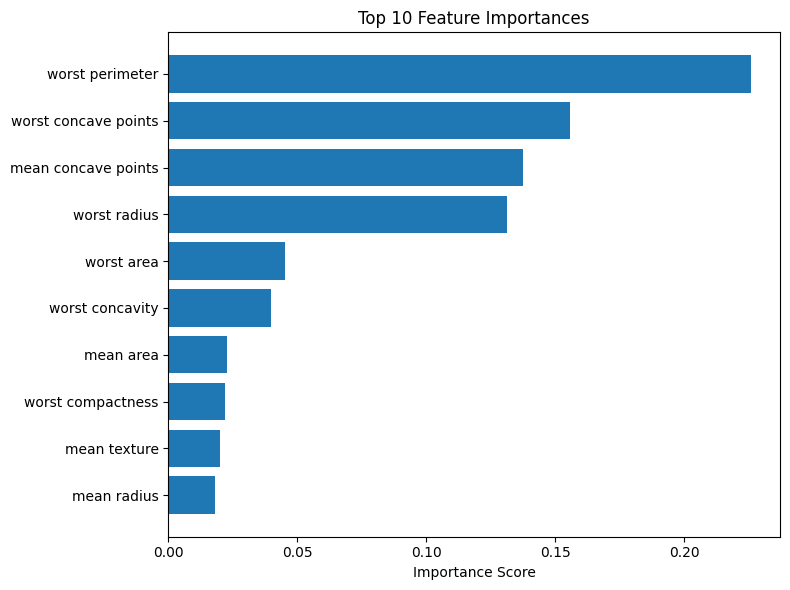

In [ ]:
# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 10

plt.figure(figsize=(8, 6))
plt.barh(
    data.feature_names[indices[:top_n]][::-1],
    importances[indices[:top_n]][::-1]
)

plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

* Feature importance in XGBoost is calculated based on the reduction in loss (objective function) achieved when a feature is used to split the data. It is typically measured by aggregating the gain (loss reduction) across all splits involving that feature.

*  The XGBoost model identified worst perimeter and concave point–related features as the most important predictors, indicating that tumor size and shape play a key role in classification.
* These features contributed the most to reducing the model’s loss during tree splits, making them the strongest drivers of prediction performance.

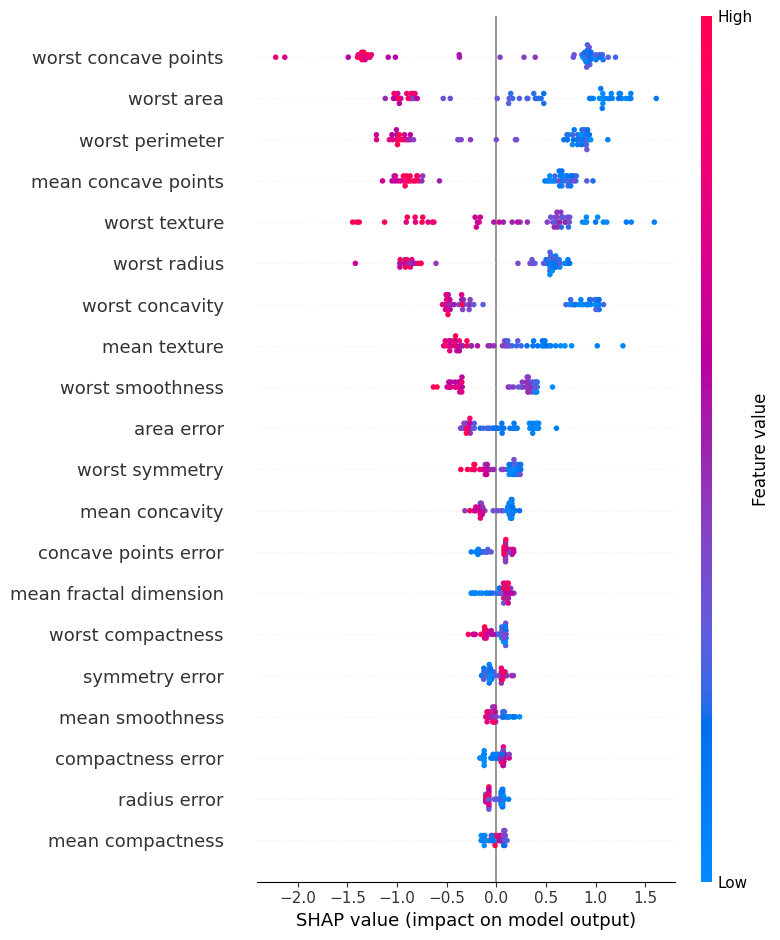

In [ ]:
import shap
import pandas as pd

explainer = shap.TreeExplainer(model)

X_test_df = pd.DataFrame(X_test, columns=data.feature_names)

shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

* SHAP values quantify how much each feature contributes to a prediction, including both the magnitude and direction of the effect. Unlike traditional feature importance, SHAP values indicate whether a feature increases or decreases the prediction.
* For example, in worst concave points, higher feature values (red) are mostly associated with negative SHAP values (left), while lower values (blue) are associated with positive SHAP values (right). This indicates that higher values push the prediction toward the benign class, whereas lower values increase the likelihood of malignancy.
* Similar inverse relationships can be observed for features such as worst concave points, worst area, and worst perimeter.

# <font color="green">**Evaluation**</font>


* We developed an XGBoost model using the optimal hyperparameters:
  * colsample_bytree = 0.8, learning_rate = 0.1, max_depth = 8, n_estimators = 300, and subsample = 0.8.

* Model performance was evaluated using classification reports and confusion matrices across the training, validation, and test sets.

* The F1 score was used as the primary evaluation metric, with additional emphasis placed on malignant recall.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# target names: malignant (0) and benign (1)
target_names = ['malignant', 'benign']


# Confusion matrix plot function
def plot_confusion_matrix(labels, predictions, title):
    conf_matrix = confusion_matrix(labels, predictions)                     # compute confusion matrix
    plt.figure(figsize=(6, 6))                                              # create figure for the plot
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)     # Display confusion matrix as an image (heatmap)
    plt.title(title)
    plt.colorbar()                                                          # Add a color scale bar
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation=45)                       # Roate X axis label for better readability
    plt.yticks(tick_marks, target_names)

    thresh = conf_matrix.max() / 2
    for i, j in np.ndindex(conf_matrix.shape):                              # Add numerical values to each cell in the confusion matrix
        plt.text(j, i, format(conf_matrix[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

### **XGboost Evaluation**

XGboost Model Evaluation:

Train Classification Report
              precision    recall  f1-score   support

   malignant       1.00      1.00      1.00       174
      benign       1.00      1.00      1.00       286

    accuracy                           1.00       460
   macro avg       1.00      1.00      1.00       460
weighted avg       1.00      1.00      1.00       460



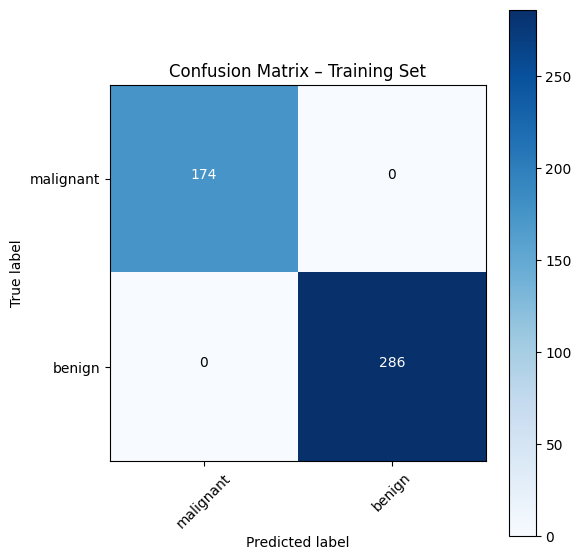

In [17]:
# make predictions for train, validation, and test datasets using base model
y_pred_train_base = (best_model.predict(X_train) > 0.5).astype("int32")
y_pred_val_base = (best_model.predict(X_val) > 0.5).astype("int32")
y_pred_test_base = (best_model.predict(X_test) > 0.5).astype("int32")


# ---- Train set Classification Report and Confusion Matrix----
print("XGboost Model Evaluation:\n")
print("Train Classification Report")
print(classification_report(y_train, y_pred_train_base, target_names=target_names))
plot_confusion_matrix(y_train, y_pred_train_base, 'Confusion Matrix – Training Set')

* The training macro-average F1 score is 1.0.

* The model achieves perfect recall for malignant cases on the training set.

* Overall, the model perfectly classifies all cancer cases in the training data.

Best Model Evaluation:

Validation Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.88      0.94        17
      benign       0.95      1.00      0.97        35

    accuracy                           0.96        52
   macro avg       0.97      0.94      0.95        52
weighted avg       0.96      0.96      0.96        52



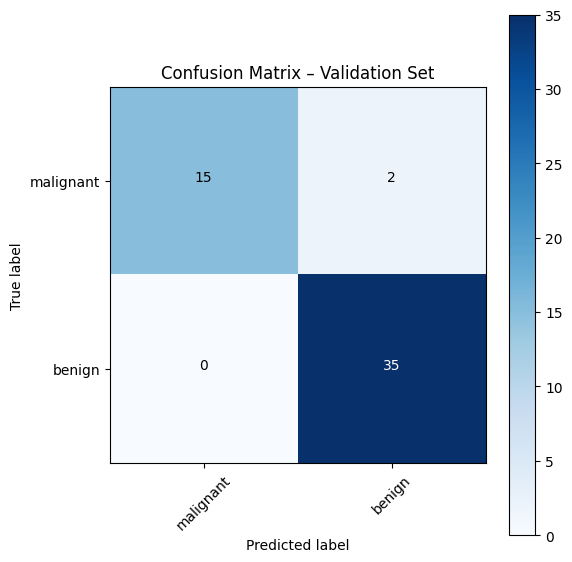

In [12]:
# ---- Validation set Classification Report and Confusion Matrix ----
print("XGboost Model Evaluation:\n")
print("Validation Classification Report")
print(classification_report(y_val, y_pred_val_base, target_names=target_names))
plot_confusion_matrix(y_val, y_pred_val_base, 'Confusion Matrix – Validation Set')

* The validation macro-average F1 score is 0.95.

* The model achieves 0.88 recall for malignant cases on the validation set.


XGboost Model Evaluation:

Test Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        21
      benign       0.97      1.00      0.99        36

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



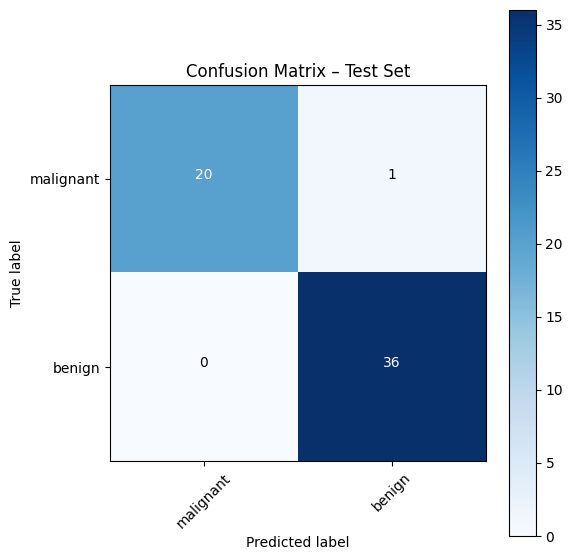

In [16]:
# ---- Test set Classification Report and Confusion Matrix ----
print("XGboost Model Evaluation:\n")
print("Test Classification Report")
print(classification_report(y_test, y_pred_test_base, target_names=target_names))
plot_confusion_matrix(y_test, y_pred_test_base, 'Confusion Matrix – Test Set')


* The test macro-average F1 score is 0.98.

* The model achieves 0.95 recall for malignant cases on the test set.


# <font color="green">**Model Comparison**</font>


* Both ANN and XGBoost achieved identical performance on the test set, indicating that the classification task can be effectively handled by both models. Despite their different learning mechanisms, no performance improvement was observed from using a more complex model.

* Given this, XGBoost is preferred due to its stability, interpretability, and computational efficiency. In particular, it is well-suited for structured tabular data and provides additional advantages such as feature importance analysis, which facilitates a clearer understanding of the factors influencing model predictions.

### Saving model

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive/")

In [ ]:
import os
os.chdir("")

In [ ]:
import joblib

joblib.dump(best_model, "xgb_breast_cancer.pkl")

['xgb_breast_cancer.pkl']